In [ ]:
import zipfile

zip_path = '/content/online+retail.zip'
extract_path = '/content/unzipped_data/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"'{zip_path}' extracted to '{extract_path}'")

'/content/online+retail.zip' extracted to '/content/unzipped_data/'


In [ ]:
# List files in the extracted directory to verify
import os
print(os.listdir(extract_path))

['Online Retail.xlsx']


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load original dataset from the unzipped directory
df = pd.read_excel(os.path.join(extract_path, "Online Retail.xlsx"))

# Recreate cleaned dataset
clean_df = df.copy()

clean_df = clean_df.drop_duplicates()
clean_df = clean_df.dropna(subset=["Description"])
clean_df = clean_df.dropna(subset=["CustomerID"])
clean_df = clean_df[~clean_df["InvoiceNo"].astype(str).str.startswith("C")]
clean_df = clean_df[clean_df["Quantity"] > 0]
clean_df = clean_df[clean_df["UnitPrice"] > 0]

# Feature engineering
clean_df["CustomerID"] = clean_df["CustomerID"].astype(int)
clean_df["TotalAmount"] = clean_df["Quantity"] * clean_df["UnitPrice"]

clean_df["Year"] = clean_df["InvoiceDate"].dt.year
clean_df["Month"] = clean_df["InvoiceDate"].dt.month
clean_df["Day"] = clean_df["InvoiceDate"].dt.day
clean_df["Hour"] = clean_df["InvoiceDate"].dt.hour

# Save cleaned dataset
clean_df.to_csv("cleaned_online_retail.csv", index=False)

print("Cleaned dataset shape:", clean_df.shape)
clean_df.head()

Cleaned dataset shape: (392692, 13)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,Year,Month,Day,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010,12,1,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010,12,1,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,8


In [ ]:
print("Dataset Shape:", clean_df.shape)
print("\nData Types:")
print(clean_df.dtypes)

print("\nDescriptive Statistics:")
print(clean_df.describe())

print("\nUnique Customers:", clean_df["CustomerID"].nunique())
print("Unique Invoices:", clean_df["InvoiceNo"].nunique())
print("Unique Products:", clean_df["StockCode"].nunique())
print("Unique Countries:", clean_df["Country"].nunique())

print("\nTotal Revenue:", clean_df["TotalAmount"].sum())
print("Total Quantity Sold:", clean_df["Quantity"].sum())

Dataset Shape: (392692, 13)

Data Types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              int64
Country                object
TotalAmount           float64
Year                    int32
Month                   int32
Day                     int32
Hour                    int32
dtype: object

Descriptive Statistics:
            Quantity                    InvoiceDate      UnitPrice  \
count  392692.000000                         392692  392692.000000   
mean       13.119702  2011-07-10 19:13:07.771892480       3.125914   
min         1.000000            2010-12-01 08:26:00       0.001000   
25%         2.000000            2011-04-07 11:12:00       1.250000   
50%         6.000000            2011-07-31 12:02:00       1.950000   
75%        12.000000            2011-10-20 12:53:00       3.750000   
max     80995.000000            2011-12-

In [ ]:
# ==========================================
# STEP 3: SALES & REVENUE ANALYSIS
# ==========================================

# Total revenue by month
monthly_revenue = (
    clean_df.groupby(["Year", "Month"])["TotalAmount"]
    .sum()
    .reset_index()
)

monthly_revenue["Period"] = (
    monthly_revenue["Year"].astype(str)
    + "-"
    + monthly_revenue["Month"].astype(str).str.zfill(2)
)

print("Monthly Revenue:")
print(monthly_revenue)

# Top 10 countries by revenue
country_revenue = (
    clean_df.groupby("Country")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
)

print("\nTop 10 Countries by Revenue:")
print(country_revenue.head(10))

# Top 10 products by quantity sold
product_quantity = (
    clean_df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

print("\nTop 10 Products by Quantity Sold:")
print(product_quantity.head(10))

# Top 10 products by revenue
product_revenue = (
    clean_df.groupby("Description")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
)

print("\nTop 10 Products by Revenue:")
print(product_revenue.head(10))

Monthly Revenue:
    Year  Month  TotalAmount   Period
0   2010     12   570422.730  2010-12
1   2011      1   568101.310  2011-01
2   2011      2   446084.920  2011-02
3   2011      3   594081.760  2011-03
4   2011      4   468374.331  2011-04
5   2011      5   677355.150  2011-05
6   2011      6   660046.050  2011-06
7   2011      7   598962.901  2011-07
8   2011      8   644051.040  2011-08
9   2011      9   950690.202  2011-09
10  2011     10  1035642.450  2011-10
11  2011     11  1156205.610  2011-11
12  2011     12   517190.440  2011-12

Top 10 Countries by Revenue:
Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: TotalAmount, dtype: float64

Top 10 Products by Quantity Sold:
Description
PAPER CRAFT , LITTLE BIRDIE     

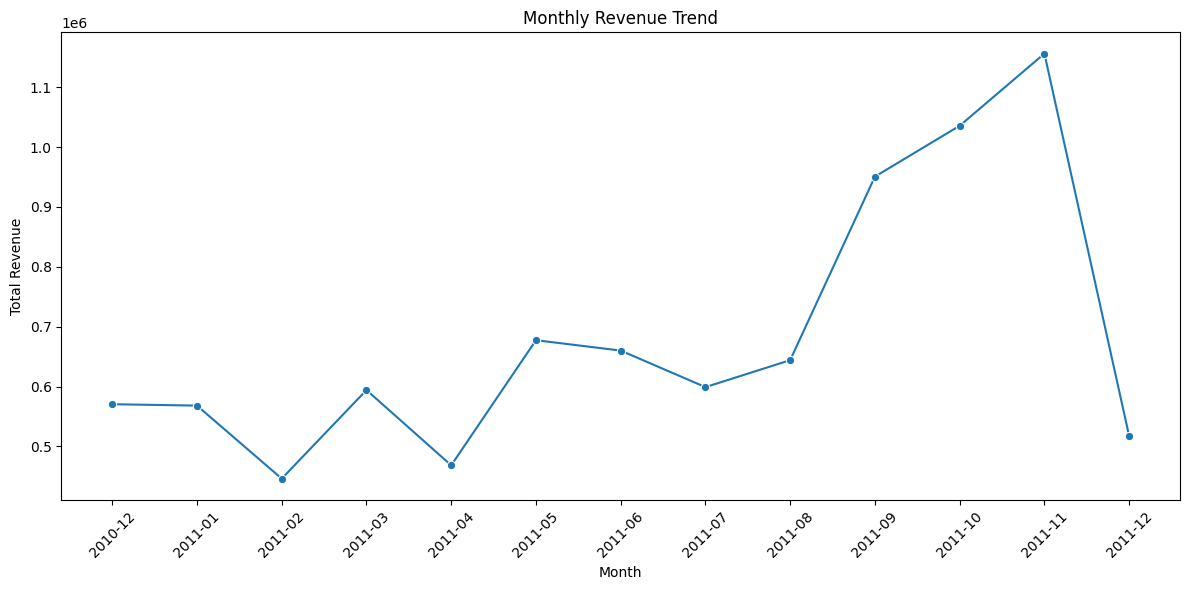

In [ ]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_revenue,
    x="Period",
    y="TotalAmount",
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

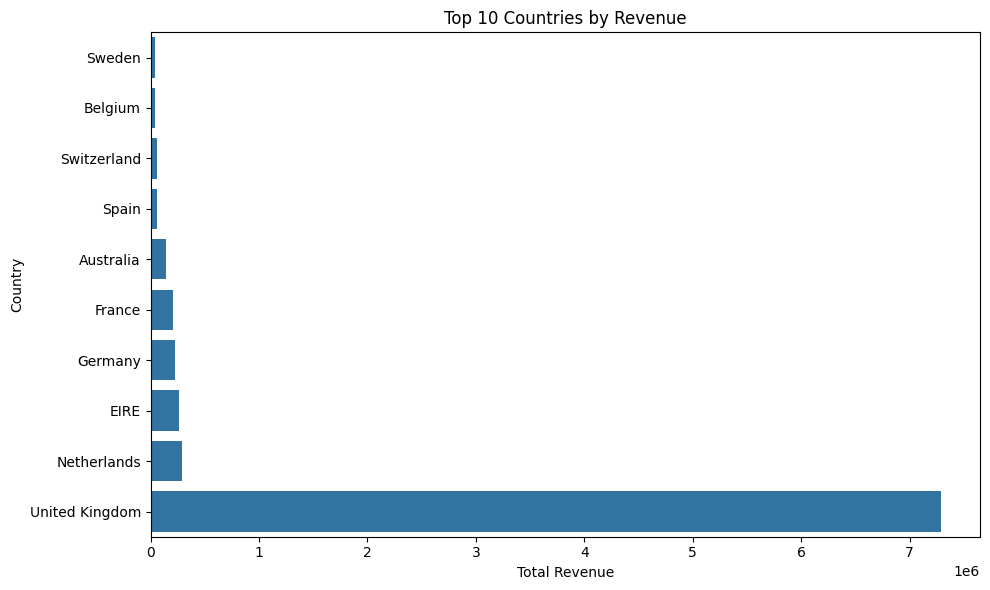

In [ ]:
# ==========================================
# VISUALIZATION 2: TOP 10 COUNTRIES
# ==========================================

top_countries = country_revenue.head(10).sort_values()

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Country")
plt.tight_layout()

plt.show()

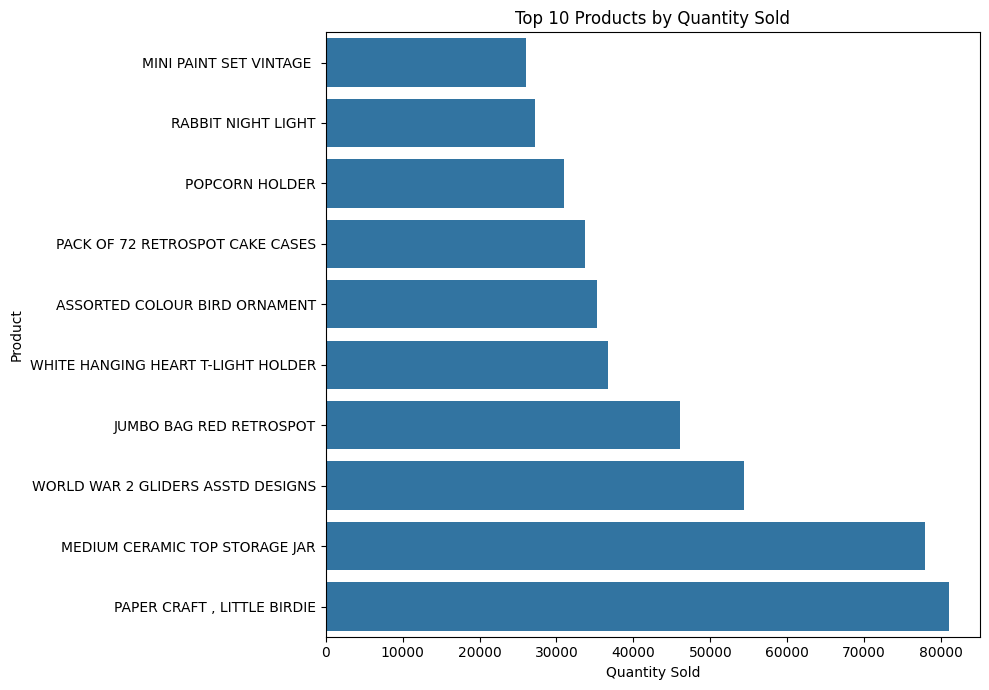

In [ ]:
# ==========================================
# VISUALIZATION 3: TOP 10 PRODUCTS
# ==========================================

top_products_quantity = product_quantity.head(10).sort_values()

plt.figure(figsize=(10, 7))

sns.barplot(
    x=top_products_quantity.values,
    y=top_products_quantity.index
)

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")
plt.tight_layout()

plt.show()

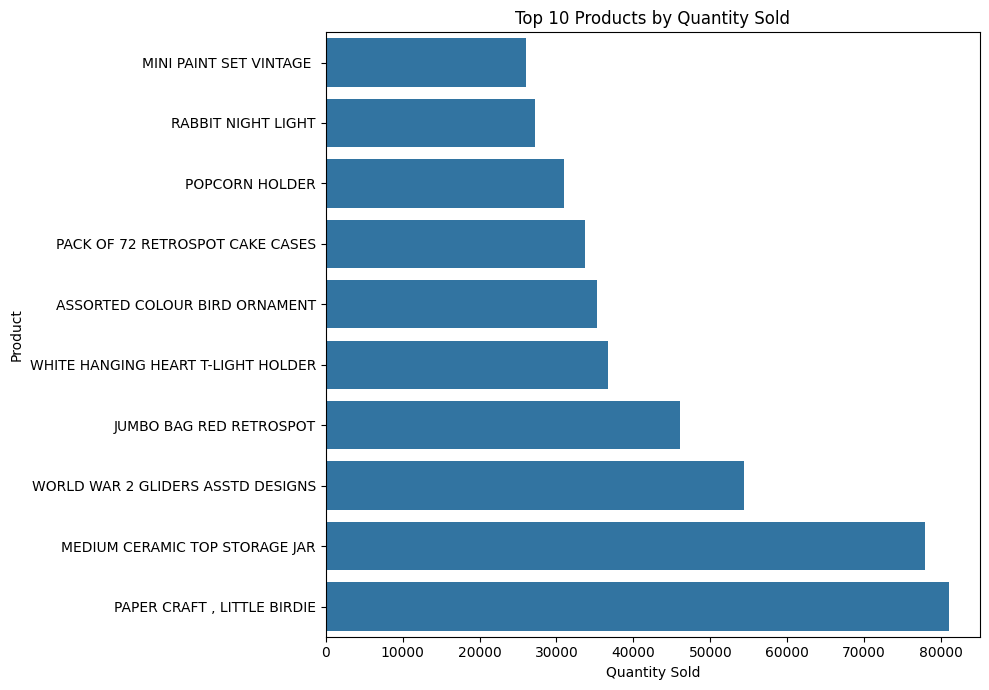

In [ ]:
top_products_quantity = product_quantity.head(10).sort_values()

plt.figure(figsize=(10, 7))

sns.barplot(
    x=top_products_quantity.values,
    y=top_products_quantity.index
)

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

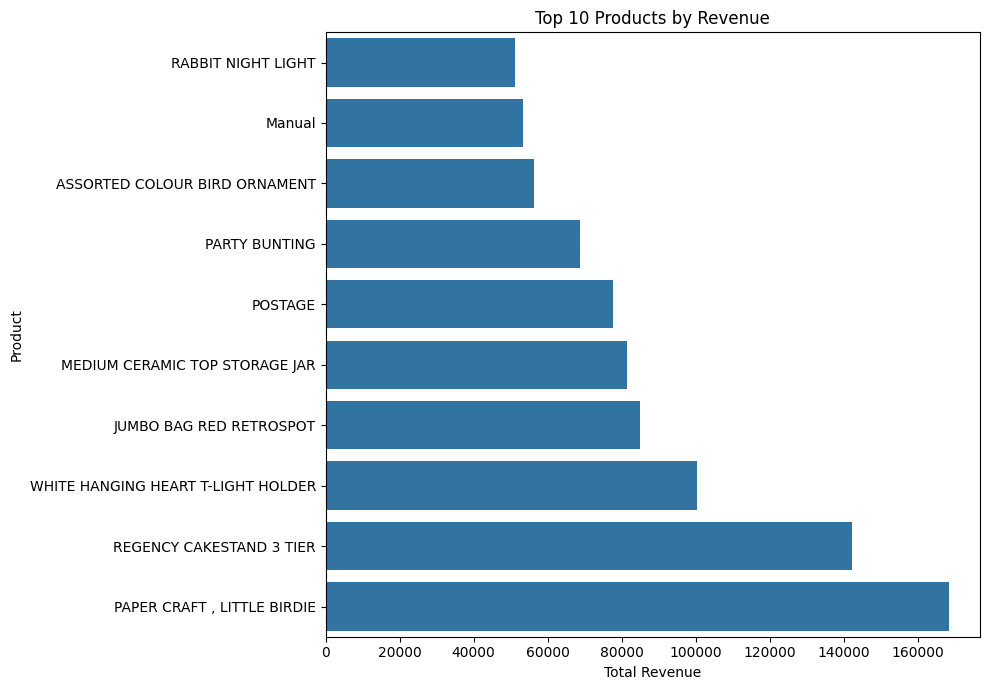

In [ ]:
top_products_revenue = product_revenue.head(10).sort_values()

plt.figure(figsize=(10, 7))

sns.barplot(
    x=top_products_revenue.values,
    y=top_products_revenue.index
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [ ]:
customer_revenue = (
    clean_df.groupby("CustomerID")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
)

top_customers = customer_revenue.head(10).sort_values()

print(top_customers)

CustomerID
12346     77183.60
16029     80850.84
17511     91062.38
14156    117210.08
12415    124914.53
14911    143711.17
16446    168472.50
17450    194390.79
18102    259657.30
14646    280206.02
Name: TotalAmount, dtype: float64


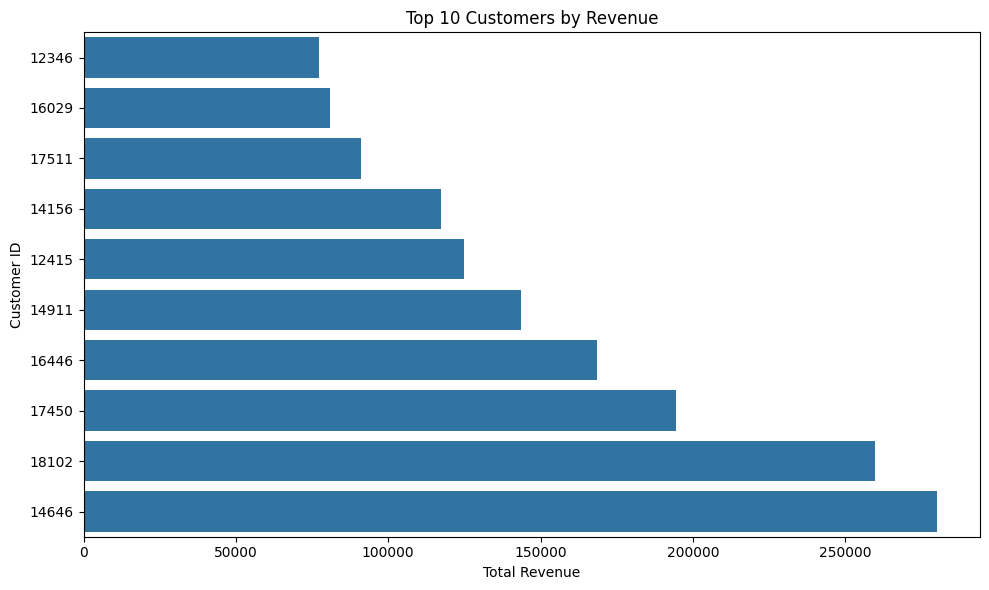

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_customers.values,
    y=top_customers.index.astype(str)
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Customer ID")
plt.tight_layout()
plt.show()

In [ ]:
customer_frequency = (
    clean_df.groupby("CustomerID")["InvoiceNo"]
    .nunique()
)

print(customer_frequency.describe())

count    4338.000000
mean        4.272015
std         7.697998
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       209.000000
Name: InvoiceNo, dtype: float64


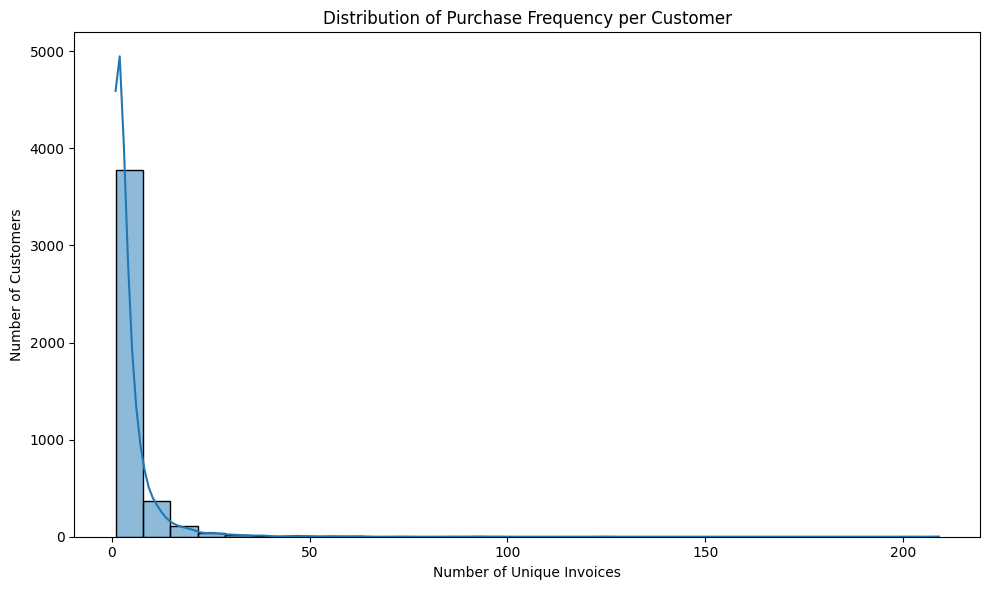

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    customer_frequency,
    bins=30,
    kde=True
)

plt.title("Distribution of Purchase Frequency per Customer")
plt.xlabel("Number of Unique Invoices")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

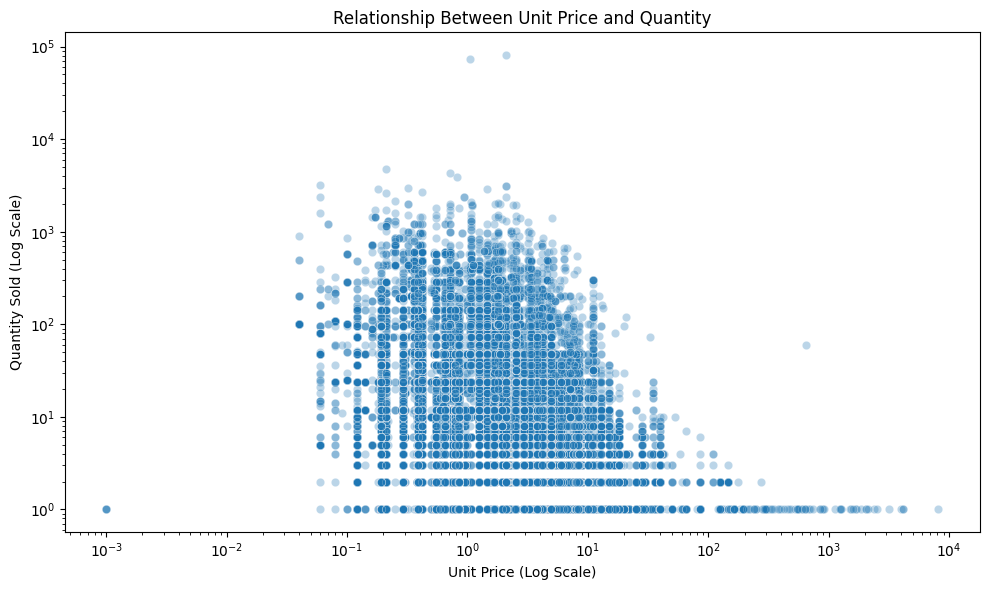

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=clean_df,
    x="UnitPrice",
    y="Quantity",
    alpha=0.3
)

plt.xscale("log")
plt.yscale("log")

plt.title("Relationship Between Unit Price and Quantity")
plt.xlabel("Unit Price (Log Scale)")
plt.ylabel("Quantity Sold (Log Scale)")
plt.tight_layout()
plt.show()

In [ ]:
hourly_revenue = (
    clean_df.groupby("Hour")["TotalAmount"]
    .sum()
    .sort_index()
)

print(hourly_revenue)

Hour
6           4.250
7       31059.210
8      281997.790
9      842392.341
10    1259267.591
11    1101177.600
12    1373695.390
13    1168724.200
14     991992.821
15     963559.680
16     467380.560
17     233811.591
18     104744.990
19      48568.400
20      18832.480
Name: TotalAmount, dtype: float64


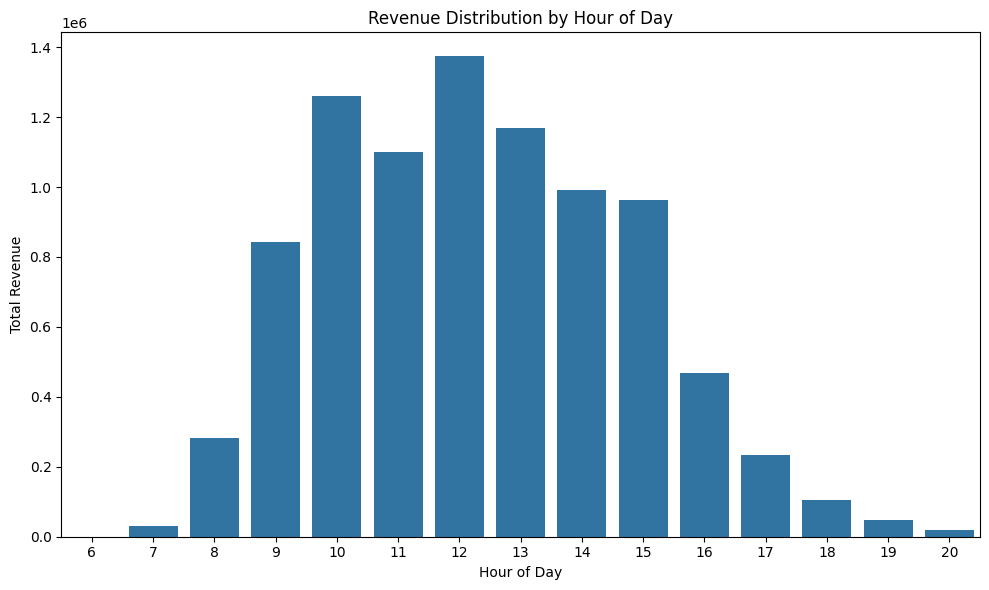

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=hourly_revenue.index,
    y=hourly_revenue.values
)

plt.title("Revenue Distribution by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

In [ ]:
correlation_data = clean_df[
    ["Quantity", "UnitPrice", "TotalAmount"]
].corr()

print(correlation_data)

             Quantity  UnitPrice  TotalAmount
Quantity     1.000000  -0.004578     0.914451
UnitPrice   -0.004578   1.000000     0.081619
TotalAmount  0.914451   0.081619     1.000000


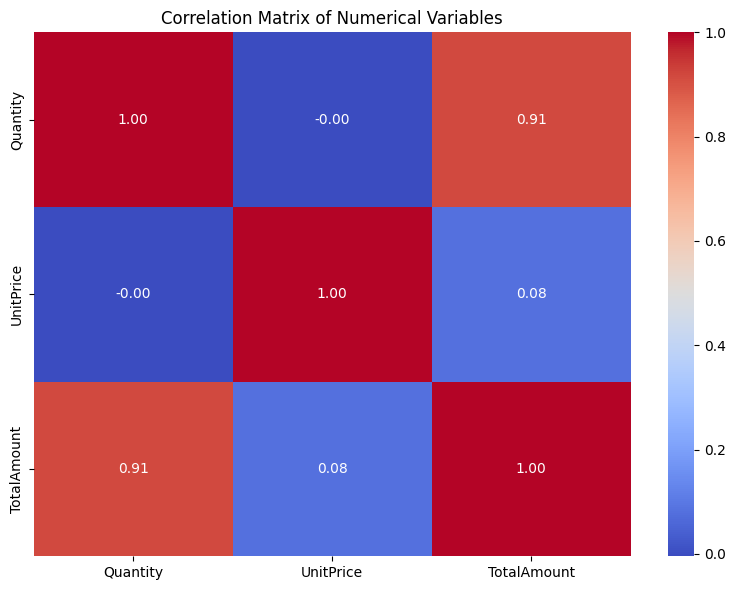

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_data,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

In [ ]:
print("=== KEY EDA FINDINGS ===")

print("\n1. Highest Revenue Month:")
print(monthly_revenue.loc[
    monthly_revenue["TotalAmount"].idxmax(),
    ["Period", "TotalAmount"]
])

print("\n2. Highest Revenue Country:")
print(country_revenue.head(5))

print("\n3. Top 5 Products by Quantity:")
print(product_quantity.head(5))

print("\n4. Top 5 Products by Revenue:")
print(product_revenue.head(5))

print("\n5. Top 5 Customers by Revenue:")
print(customer_revenue.head(5))

print("\n6. Purchase Frequency:")
print(customer_frequency.describe())

print("\n7. Numerical Correlation:")
print(correlation_data)

=== KEY EDA FINDINGS ===

1. Highest Revenue Month:
Period            2011-11
TotalAmount    1156205.61
Name: 11, dtype: object

2. Highest Revenue Country:
Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Name: TotalAmount, dtype: float64

3. Top 5 Products by Quantity:
Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
Name: Quantity, dtype: int64

4. Top 5 Products by Revenue:
Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
Name: TotalAmount, dtype: float64

5. Top 5 Customers by Revenue:
CustomerI